# From a business risk to a forward or swap

**The decision:** when should a compute business commit to physical delivery, settle a price difference in cash, receive a fixed price, or pay a fixed price?

This companion follows the narrative format of [From a business risk to a compute hedge](https://github.com/zach189/education/blob/main/notebooks/case_hedge_converter.ipynb). Each story introduces the participants, their concern, the dollars at risk, the contract, its price, and what happens afterward. No finance background is required.

All people, quotes, curves, costs, and contracts below are **hypothetical teaching inputs**. They are not live compute quotes or evidence that these products are available. Outputs are saved, so you can read without running Python. To experiment, change inputs and rerun from the top; prose describes the original inputs. The notebook is standalone and uses only standard Python and Matplotlib, which is included in Google Colab.

We separate three questions throughout:

1. **Sizing:** how many hours need protection?
2. **Pricing:** what fixed rate can the parties agree, and is anything paid upfront?
3. **Outcome:** what do the business and hedge pay when prices change?

A target or break-even rate explains what a business wants. It does not establish the rate a counterparty will offer.


## 1. Vocabulary, attached to a payment

One **GPU-hour** is one GPU available for one hour under the specified service terms. A price of USD 3 per GPU-hour times 100,000 hours is USD 300,000.

A **forward** is a binding agreement made today for a future transaction. In our physical example, the seller provides compute service and the buyer pays the agreed price. “Physical” means delivery of usable service, not shipping ownership of the GPUs. In our cash example, only a price difference is paid; the buyer must obtain compute separately.

A **swap** exchanges payments calculated in two different ways. Our swaps compare a fixed USD/GPU-hour rate with a changing index rate each month. A **leg** is one of those payment calculations. A **reference index** is the agreed price series used to calculate the changing, or **floating**, leg. **Net settlement** means only the difference changes hands.

The **notional quantity** is the number of hours used to calculate cash payments. It is not an upfront purchase price. The **fixed rate** is the agreed rate; the **settlement index** is the observed price used later. A positive hedge cash flow means the person in the story receives money; a negative one means they pay.

| Contract position | Cash receipt per settlement | Business exposure it can offset |
|---|---|---|
| Buy a cash forward | (Index − fixed rate) × hours | A future purchase becoming more expensive |
| Sell a cash forward | (Fixed rate − index) × hours | A future sale earning less |
| Receive fixed, pay floating | (Fixed rate − index) × monthly hours | Recurring sales at changing prices |
| Receive floating, pay fixed | (Index − fixed rate) × monthly hours | Recurring purchases at changing prices |

These are signed differences. Unlike a purchased option, there is **no instruction to replace a negative result with zero**. Either side can owe money. A one-period cash swap and a matched cash forward can have the same economics; labels do not replace reading the actual terms. Our distinction is one service period versus recurring monthly periods. [1–3]


In [1]:
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def usd(value):
    return f"USD {value:,.2f}"

def receive_fixed(fixed_rate, index_rate, hours):
    return (fixed_rate - index_rate) * hours

def receive_floating(fixed_rate, index_rate, hours):
    return (index_rate - fixed_rate) * hours

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})


## 2. Nina and Arun: a physical forward secures a customer and capacity

**The participants.** Nina runs a compute operator. Arun runs an AI lab planning a training job. They transact directly; there is no separate hedge dealer in this story.

**What Nina is worried about:** “I have committed to pay for 100,000 hours in month 6. If customers pay less by then, I could lose my margin. I would also like a customer committed to taking that block.”

**What Arun is worried about:** “My training job needs that block in month 6. I want an agreed price and a supplier committed to providing the service.”

**What they want to protect.** Nina wants a USD 100,000 contribution above her USD 200,000 contracted supply cost. Arun wants a known USD 300,000 bill and defined capacity. Contribution means revenue less the specified supply cost; it is not profit after every business expense.

**How the forward helps.** Nina agrees now to deliver 100,000 specified GPU-hours during month 6. Arun agrees to pay for the full block even if he uses fewer hours. Nina must make the capacity available; unused hours expire at the end of the window under these assumed terms. Payment is due at month-end, with no initial deposit in this example.

### Price and quantity

| Input | Value | Why it matters |
|---|---:|---|
| Contracted block | 100,000 GPU-hours | Physical quantity to deliver and pay for |
| Nina's supply cost | USD 2/hour | Her assumed cost on the entire block |
| Nina's physical offer, accepted by Arun | USD 3/hour | Negotiated selling price, supplied as an input |
| Service window | Month 6 | When the specified service must be available |
| Payment | End of month 6 | Both purchase and sale cash flows assumed aligned |

**Pricing the deal:** Nina offers USD 3, and Arun accepts. Therefore Arun's invoice is 100,000 × USD 3 = **USD 300,000**. Nina pays **USD 200,000** for supply and keeps a **USD 100,000 contribution**. Her cost explains her margin; it does not prove USD 3 is a competitive market price.

We assume the GPU model, region, interconnect, concurrent GPU count, availability schedule, and service level are agreed. An hour total alone does not ensure a training job can run.


In [2]:
physical_hours = 100_000
physical_rate = 3.00
supply_rate = 2.00
physical_invoice = physical_hours * physical_rate
supply_bill = physical_hours * supply_rate
print("Arun's committed invoice:", usd(physical_invoice))
print("Nina's committed supply bill:", usd(supply_bill))
print("Nina's contribution:", usd(physical_invoice - supply_bill))
for market in [1.00, 3.00, 5.00]:
    spot_comparison = market * physical_hours
    print(f"Market {market:.2f}/hour: Arun pays {usd(physical_invoice)}; "
          f"saving versus an equivalent market purchase {usd(spot_comparison - physical_invoice)}")


Arun's committed invoice: USD 300,000.00
Nina's committed supply bill: USD 200,000.00
Nina's contribution: USD 100,000.00
Market 1.00/hour: Arun pays USD 300,000.00; saving versus an equivalent market purchase USD -200,000.00
Market 3.00/hour: Arun pays USD 300,000.00; saving versus an equivalent market purchase USD 0.00
Market 5.00/hour: Arun pays USD 300,000.00; saving versus an equivalent market purchase USD 200,000.00


### Follow the outcome

| Equivalent market rate in month 6 | Arun pays Nina | Nina's supply cost | Nina's contribution | Arun's saving versus buying at that market rate |
|---|---:|---:|---:|---:|
| USD 1/hour | USD 300,000 | USD 200,000 | USD 100,000 | −USD 200,000 |
| USD 3/hour | USD 300,000 | USD 200,000 | USD 100,000 | USD 0 |
| USD 5/hour | USD 300,000 | USD 200,000 | USD 100,000 | USD 200,000 |

There is **no separate price-difference payment** in this physical forward. Arun pays the fixed invoice and Nina delivers the service. The final column is a comparison with an alternative purchase, not cash received from a hedge.

**What remains exposed.** Arun pays for the full block even if the job shrinks. Nina must deliver even if her upstream supplier fails; replacement service might cost more. Each relies on the other performing. The commitment reduces sales uncertainty for this block but does not eliminate credit or delivery risk. Unlike prepayment, an end-of-month invoice does not fund Nina's earlier deposits.

**Pause:** If the market falls to USD 1, may Arun choose the cheaper market instead and cancel this contract for free? No: that choice would require negotiated cancellation rights, an unwind agreement, or an option.


## 3. Bea and a dealer: a cash forward fixes a purchase price while sourcing stays separate

**The participants.** Bea manages compute buying for another lab. A hypothetical dealer takes the opposite financial position. Bea will buy the actual service from a supplier selected separately.

**What Bea is worried about:** “I need 100,000 hours in month 6. I want to settle the price exposure now, but I am still comparing suppliers.”

**What she wants to protect.** The cost of those 100,000 hours against a rising benchmark price. She accepts giving up the benefit of a benchmark price decline on the covered quantity.

**How the forward helps.** Bea buys a cash-settled forward at USD 3/hour. At the end of month 6, the dealer pays her `(index − 3) × 100,000` if positive. Bea pays the dealer if it is negative. The agreed index is the arithmetic average of the daily observations during month 6; both sides agree the exact series and eligible observation days.

### Price and quantity

The dealer's **hypothetical executable quote** for this precise month-average contract is USD 3/hour. We take it as an input rather than deriving it from today's spot price or Bea's budget. The notional is 100,000 GPU-hours. The agreed upfront contract payment is zero; collateral is treated separately later.

For the first calculation, Bea's supplier bills her at exactly the same month-average index for exactly 100,000 hours. Both the supplier invoice and forward settle at month-end. These matching assumptions make the offset exact.


In [3]:
cash_hours = 100_000
cash_fixed = 3.00
for index in [1.00, 3.00, 5.00]:
    bill = cash_hours * index
    forward_receipt = receive_floating(cash_fixed, index, cash_hours)
    print(f"Index {index:.2f}: supplier {usd(bill)}, "
          f"forward receipt {usd(forward_receipt)}, "
          f"combined cost {usd(bill - forward_receipt)}")


Index 1.00: supplier USD 100,000.00, forward receipt USD -200,000.00, combined cost USD 300,000.00
Index 3.00: supplier USD 300,000.00, forward receipt USD 0.00, combined cost USD 300,000.00
Index 5.00: supplier USD 500,000.00, forward receipt USD 200,000.00, combined cost USD 300,000.00


### Follow the outcome

| Month-average index | Supplier invoice | Cash forward receipt to Bea | Combined cost: invoice minus receipt |
|---|---:|---:|---:|
| USD 1/hour | USD 100,000 | −USD 200,000 | **USD 300,000** |
| USD 3/hour | USD 300,000 | USD 0 | **USD 300,000** |
| USD 5/hour | USD 500,000 | USD 200,000 | **USD 300,000** |

At USD 1, Bea pays **two different people**: USD 100,000 to the supplier and USD 200,000 to the dealer. At USD 5, she pays the supplier USD 500,000 and receives USD 200,000 from the dealer. The dealer never supplies compute.

**The other side.** The dealer sells this forward and has the opposite cash flows. A compute seller with a matching physical exposure could also sell a cash forward: physical receipts plus `(3 − index) × hours` would fix its revenue at USD 300,000. A dealer may offset its position elsewhere; its willingness to trade and its price are not assumed market facts.

**What remains exposed.** Bea still needs available capacity. If her supplier charges the index **plus USD 0.30/hour**, her combined bill is USD 330,000. That difference is **basis risk**: the hedge tracks a different price from her invoice. If her need disappears, her forward obligation remains.


In [4]:
supplier_index = 5.00
supplier_basis = 0.30
actual_bill = (supplier_index + supplier_basis) * cash_hours
hedge_receipt = receive_floating(cash_fixed, supplier_index, cash_hours)
print("Extra cost left by supplier basis:", usd(supplier_basis * cash_hours))
print("Combined cost with basis:", usd(actual_bill - hedge_receipt))


Extra cost left by supplier basis: USD 30,000.00
Combined cost with basis: USD 330,000.00


## 4. Omar and a dealer: receive fixed, pay floating to stabilize sales revenue

**The participants.** Omar runs a capacity reseller in a special-purpose company, or **SPV**: a company created to hold this particular business and its contracts. It has committed to buy capacity at USD 2/hour. Customers pay changing market prices. A dealer provides a separate cash-settled swap.

**What Omar is worried about:** “My supply bill is fixed. My customers' prices change each month. A price drop could erase the money left to cover our other obligations.”

**What he wants to protect.** Revenue from 100,000 billed GPU-hours in each of months 1, 2, and 3. For now, assume every hour sells at that month's index and the SPV pays USD 200,000 per month for supply.

**How the swap helps.** Omar **receives fixed and pays floating** on 100,000 hours each month. The swap receipt equals `(fixed rate − monthly index) × 100,000`. He continues invoicing customers independently. Only the net swap difference is transferred.

### Price the fixed rate from three forward quotes

A **forward curve** lists prices quoted today for different future periods. Suppose the following matching cash-forward rates are available as hypothetical mid-market inputs:

| Service and settlement period | Forward quote today | Covered hours |
|---|---:|---:|
| Month 1 | USD 2.80/hour | 100,000 |
| Month 2 | USD 3.00/hour | 100,000 |
| Month 3 | USD 3.20/hour | 100,000 |

These are prices for future month-average settlements, not predictions guaranteed to occur. For this introductory calculation, set financing/discounting to zero and exclude dealer spread, credit charges, and fees. The three forwards represent fixed cash amounts of USD 280,000, USD 300,000, and USD 320,000: **USD 900,000 across 300,000 hours**.

One flat swap rate with the same starting value is therefore **USD 900,000 ÷ 300,000 = USD 3/hour**. This is the **par rate** in our simplified model: the fixed rate that makes the two legs have equal value initially. There is no upfront price payment under these assumptions. The appendix adds discounting and unequal quantities. [4]

Omar cannot choose USD 4 just because he wants more margin and expect the same zero-upfront terms. That would be a more valuable promise from the dealer.


In [5]:
forward_quotes = [2.80, 3.00, 3.20]
monthly_hours = [100_000, 100_000, 100_000]
swap_fixed = sum(f*q for f, q in zip(forward_quotes, monthly_hours)) / sum(monthly_hours)
print("Three-period quoted amount:", usd(sum(f*q for f, q in zip(forward_quotes, monthly_hours))))
print(f"Flat par fixed rate, without discounting: USD {swap_fixed:.4f}/hour")

realized_indices = [1.00, 3.00, 5.00]  # Outcomes, not the earlier forward quotes.
omars_contributions = []
for month, (index, hours) in enumerate(zip(realized_indices, monthly_hours), 1):
    sales = index * hours
    swap_receipt = receive_fixed(swap_fixed, index, hours)
    supply = supply_rate * hours
    contribution = sales + swap_receipt - supply
    omars_contributions.append(contribution)
    print(f"Month {month}: sales {usd(sales)}, swap receipt {usd(swap_receipt)}, "
          f"supply {usd(supply)}, contribution {usd(contribution)}")
print("Three-month contribution:", usd(sum(omars_contributions)))


Three-period quoted amount: USD 900,000.00
Flat par fixed rate, without discounting: USD 3.0000/hour
Month 1: sales USD 100,000.00, swap receipt USD 200,000.00, supply USD 200,000.00, contribution USD 100,000.00
Month 2: sales USD 300,000.00, swap receipt USD 0.00, supply USD 200,000.00, contribution USD 100,000.00
Month 3: sales USD 500,000.00, swap receipt USD -200,000.00, supply USD 200,000.00, contribution USD 100,000.00
Three-month contribution: USD 300,000.00


### Follow the outcome

| Month | Actual index | Customer receipts | Swap receipt to Omar | Supply bill | Combined contribution |
|---|---:|---:|---:|---:|---:|
| 1 | USD 1/hour | USD 100,000 | USD 200,000 | USD 200,000 | **USD 100,000** |
| 2 | USD 3/hour | USD 300,000 | USD 0 | USD 200,000 | **USD 100,000** |
| 3 | USD 5/hour | USD 500,000 | −USD 200,000 | USD 200,000 | **USD 100,000** |

In month 3, “receive fixed” does **not** mean Omar always receives a net cash payment. The fixed calculation is USD 300,000; the floating calculation is USD 500,000. Netting them leaves **USD 200,000 payable by Omar**. His stronger customer receipts offset it.

The dealer has the opposite swap position: receive floating, pay fixed. It receives USD 200,000 in month 3 but owes USD 200,000 in month 1. Those are financial cash flows; the dealer is not one of Omar's physical customers.

**What remains exposed.** This contribution assumes all hours sell, at the exact index, at the assumed supply cost, with everyone paying. It excludes overhead, financing, tax, and other costs. The swap does not fill idle capacity. Customer payments and collateral calls may also arrive at different times.


## 5. Imani and a dealer: receive floating, pay fixed to stabilize compute costs

**The participants.** Imani manages a lab's ongoing training budget. She uses multiple physical suppliers, each assumed to charge the same reference index. A dealer provides her swap.

**What Imani is worried about:** “I need compute every month. A price spike could force us to cut the training schedule or request more funding.”

**What she wants to protect.** The cost of 100,000 GPU-hours per month for three months. She accepts paying a fixed effective price even if market compute becomes cheaper.

**How the swap helps.** Imani **receives floating and pays fixed**. Her receipt is `(monthly index − fixed rate) × hours`. This offsets changes in her supplier invoices.

### Price and quantity

Use the same hypothetical curve, quantities, and zero-discounting assumptions as Omar's independent story. The fixed rate is therefore **USD 3/hour**, the notional is **100,000 hours each month**, and the upfront price payment is zero. Her covered three-month effective spending is **USD 900,000**, assuming exact matching and performance.

Imani's and Omar's swaps are opposite positions. In principle they could be counterparties if every term matched; in these stories each deals independently with a dealer. We do not assume either actually finds such a market.


In [6]:
imanis_costs = []
for month, (index, hours) in enumerate(zip(realized_indices, monthly_hours), 1):
    supplier_bill = index * hours
    swap_receipt = receive_floating(swap_fixed, index, hours)
    combined_cost = supplier_bill - swap_receipt
    imanis_costs.append(combined_cost)
    print(f"Month {month}: supplier bill {usd(supplier_bill)}, "
          f"swap receipt {usd(swap_receipt)}, combined cost {usd(combined_cost)}")
print("Three-month combined cost:", usd(sum(imanis_costs)))


Month 1: supplier bill USD 100,000.00, swap receipt USD -200,000.00, combined cost USD 300,000.00
Month 2: supplier bill USD 300,000.00, swap receipt USD 0.00, combined cost USD 300,000.00
Month 3: supplier bill USD 500,000.00, swap receipt USD 200,000.00, combined cost USD 300,000.00
Three-month combined cost: USD 900,000.00


### Follow the outcome

| Month | Actual index | Supplier invoice | Swap receipt to Imani | Combined cost |
|---|---:|---:|---:|---:|
| 1 | USD 1/hour | USD 100,000 | −USD 200,000 | **USD 300,000** |
| 2 | USD 3/hour | USD 300,000 | USD 0 | **USD 300,000** |
| 3 | USD 5/hour | USD 500,000 | USD 200,000 | **USD 300,000** |

At USD 1, Imani's cheaper supplier invoice comes with a swap payment she owes. At USD 5, the swap pays toward the larger invoice. Her fixed budget comes with a commitment in both directions.

**What remains exposed.** She still needs suppliers to provide suitable capacity. Different supplier prices leave basis risk. A smaller workload leaves excess hedged quantity. If her supplier already charges a fixed rate, adding this pay-fixed swap would add price exposure rather than remove the floating-price exposure assumed here.

**Pause:** Does the swap let Imani choose the fixed price when prices rise but keep the lower market price when prices fall? No. That asymmetric choice is what a purchased call can provide, at a premium.


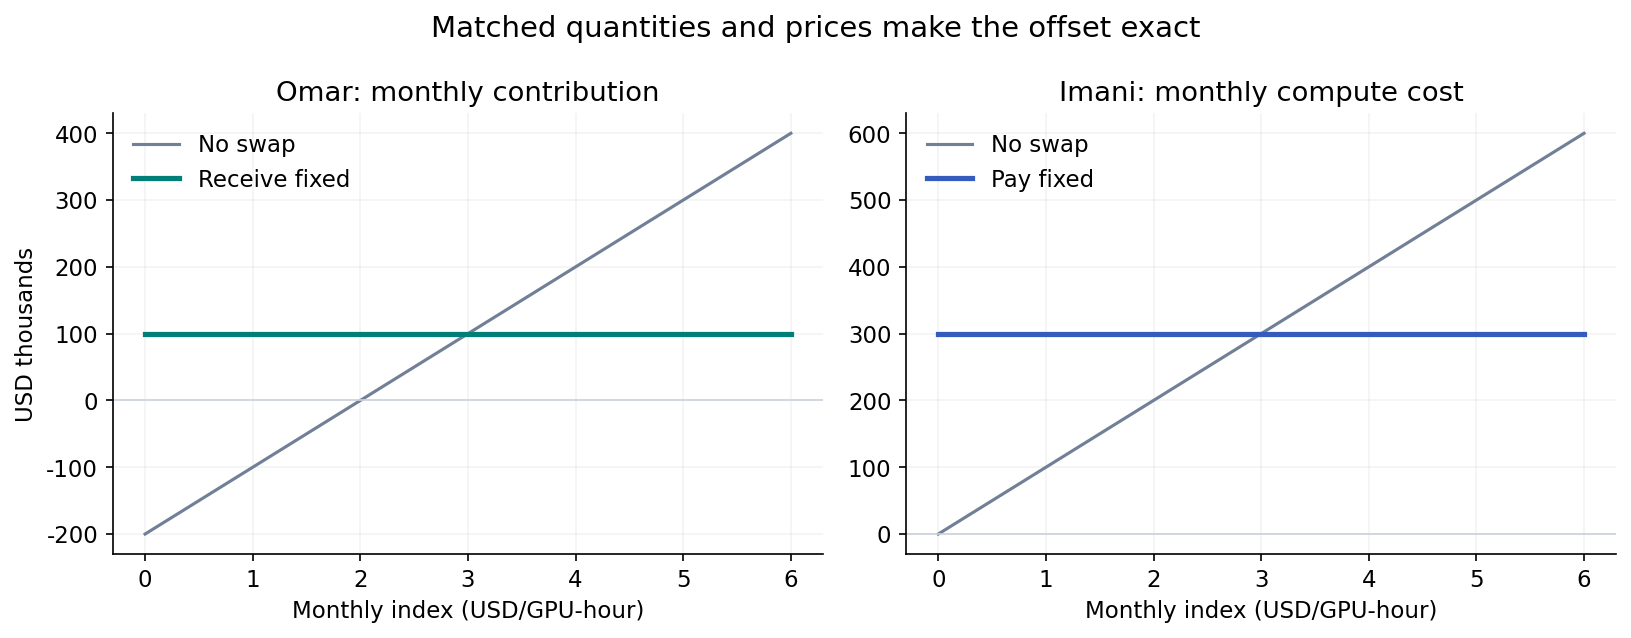

In [7]:
price_grid = [i / 20 for i in range(121)]
q = 100_000
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(price_grid, [(s-2)*q for s in price_grid], label="No swap", color="#718096")
axes[0].plot(price_grid, [(s-2)*q + receive_fixed(3, s, q) for s in price_grid],
             label="Receive fixed", color="#007f78", linewidth=2.5)
axes[0].set(title="Omar: monthly contribution", ylabel="USD thousands")
axes[1].plot(price_grid, [s*q for s in price_grid], label="No swap", color="#718096")
axes[1].plot(price_grid, [s*q - receive_floating(3, s, q) for s in price_grid],
             label="Pay fixed", color="#355cbd", linewidth=2.5)
axes[1].set(title="Imani: monthly compute cost")
for ax in axes:
    ax.set_xlabel("Monthly index (USD/GPU-hour)")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:,.0f}"))
    ax.axhline(0, color="#ccd2db", linewidth=.8)
    ax.grid(alpha=.15)
    ax.legend(frameon=False)
fig.suptitle("Matched quantities and prices make the offset exact", fontsize=14)
fig.tight_layout()
plt.show()


## 6. Omar's sales fall to 60%: a fixed price is not a fixed profit

**The changed problem:** Omar still owes USD 200,000 for 100,000 hours, and his swap still covers 100,000 hours. But he now finds customers for only **60,000 hours**. The remaining 40,000 expire unused. His supply commitment does not shrink.

The original swap was sized to assumed sales. It now covers 40,000 more hours than he actually sells. That is an **overhedge**.

| Actual index | Sales of 60,000 hours | Receipt on 100,000-hour swap | Committed supply bill | Combined contribution |
|---|---:|---:|---:|---:|
| USD 1/hour | USD 60,000 | USD 200,000 | USD 200,000 | **USD 60,000** |
| USD 3/hour | USD 180,000 | USD 0 | USD 200,000 | **−USD 20,000** |
| USD 5/hour | USD 300,000 | −USD 200,000 | USD 200,000 | **−USD 100,000** |

When the price rises, the swap payment grows on all 100,000 hours, but Omar earns the higher price on only 60,000 hours. The unbacked 40,000-hour hedge creates exposure to rising prices. The USD 60,000 outcome at a low price is also not evidence of a utilization guarantee: a differently sized or absent hedge would behave differently.

If he had originally hedged **60,000 hours at USD 3**, his contribution would be **USD 180,000 − USD 200,000 = −USD 20,000** in all three price cases. This removes that price mismatch but does not repair the loss on unused supply. Reducing an existing swap later may require an unwind payment; it is not assumed free.


In [8]:
sold_hours = 60_000
committed_hours = 100_000
for index in [1.00, 3.00, 5.00]:
    revenue = sold_hours * index
    supply = committed_hours * 2.00
    oversized = revenue + receive_fixed(3.00, index, committed_hours) - supply
    matched = revenue + receive_fixed(3.00, index, sold_hours) - supply
    print(f"Index {index:.2f}: 100k-hour hedge contribution {usd(oversized)}; "
          f"60k-hour hedge contribution {usd(matched)}")


Index 1.00: 100k-hour hedge contribution USD 60,000.00; 60k-hour hedge contribution USD -20,000.00
Index 3.00: 100k-hour hedge contribution USD -20,000.00; 60k-hour hedge contribution USD -20,000.00
Index 5.00: 100k-hour hedge contribution USD -100,000.00; 60k-hour hedge contribution USD -20,000.00


## 7. What is the price, what is the value, and what cash is needed today?

These are different amounts:

| Term | Meaning in our stories |
|---|---|
| Fixed rate | USD 3/hour agreed for calculating future invoices or settlements |
| Physical invoice | USD 300,000 for delivery of 100,000 hours |
| Upfront contract payment | Assumed zero for our new at-market forwards and swaps |
| Contract value | What the remaining contractual cash flows are worth at current quotes |
| Collateral | Cash or other agreed assets posted to support performance; not an option premium |

**Why no option premium?** Both parties make binding promises. One party benefits from an adverse-to-the-other price move, and the other party benefits from the opposite move. Setting an at-market fixed rate can balance those promises initially. This does not make a swap riskless or free to maintain. Dealer spreads, credit terms, collateral funding, and termination costs can matter.

### A forward can become valuable before it settles

Bea locked USD 3 for 100,000 hours. Suppose, before the observation month begins, an otherwise identical forward is now quoted at USD 4. Ignoring discounting and credit adjustments, her old buy-forward is worth approximately **(4 − 3) × 100,000 = USD 100,000**. If the replacement quote is USD 2, its value is **−USD 100,000**.

This uses today's **replacement forward quote for the remaining exposure**, not today's spot price and not the eventual realized index. At final settlement, the observed index determines the payment. A calculated positive value is not automatically cash she can withdraw; exiting requires agreed termination or an offsetting transaction, and an offset does not necessarily cancel the original contract.

### A good hedge can still require cash early

Suppose all three months of Omar's swap are still outstanding, and their replacement forward quotes rise to USD 4/hour. Ignoring discounting, his receive-fixed USD 3 swap has a value of **−USD 300,000**. Assume a hypothetical agreement calls for collateral equal to that negative value, with no threshold and no collateral already posted. Omar must then post **USD 300,000 now**, while his stronger customer receipts arrive later.

That collateral requirement is an assumption, not a universal margin rule. Collateral is tracked and returned or applied under the agreement; do not subtract it again as a second economic loss when calculating final settlement. Its immediate funding need is nevertheless real. [3]


In [9]:
replacement_forward = 4.00
bea_value = (replacement_forward - cash_fixed) * cash_hours
omar_value = sum((swap_fixed - replacement_forward) * q for q in monthly_hours)
assumed_collateral_call = max(-omar_value, 0)
print("Bea's approximate forward value:", usd(bea_value))
print("Omar's approximate swap value:", usd(omar_value))
print("Omar's collateral call under the stated assumption:", usd(assumed_collateral_call))


Bea's approximate forward value: USD 100,000.00
Omar's approximate swap value: USD -300,000.00
Omar's collateral call under the stated assumption: USD 300,000.00


## 8. Translate each story into a request for a quote

A **request for quote (RFQ)** asks a potential counterparty for a price on specified terms. It does not execute a trade.

| Story | Product and direction | Quantity | Price requested | Delivery or reference | Timing |
|---|---|---|---|---|---|
| Nina / Arun | Sell / buy physical forward | 100,000 hours | Fixed physical service rate | Exact service, location, concurrent capacity, schedule, and availability obligations | Service during month 6; invoice at month-end |
| Bea | Buy cash forward | 100,000 hours | Fixed forward rate | Agreed month-average compute index | Observe month 6; cash payment at month-end |
| Omar | Receive fixed / pay floating swap | 100,000 hours per month | Flat fixed swap rate | Same defined monthly index | Monthly observations and payments, months 1–3 |
| Imani | Receive floating / pay fixed swap | 100,000 hours per month | Flat fixed swap rate | Same defined monthly index | Monthly observations and payments, months 1–3 |

For a real quote, replace month numbers with calendar dates. Specify hardware/service eligibility, currency, observation days and averaging weights, index disruption fallbacks, invoice and payment dates, and quantity for each period. Ask for the upfront payment, bid/offer terms, collateral rules, and early-termination terms. A physical deal also needs an agreed response to under-delivery and service failure.

The notebook's USD 3 prices are teaching inputs or simplified curve calculations. A cash index hedge and a physical capacity commitment need not quote at the same rate: their service, credit, delivery, and payment terms can differ.

**Choose the instrument around the obligation you want.** A physical forward commits both capacity and payment. A cash forward fixes a single period's benchmark price exposure while leaving sourcing or sales separate. A monthly swap repeats that price exchange across periods. Each fixes a price only for the quantity and reference specified.


## Optional appendix A. Add payment timing to the swap price

**Discounting** converts money received later into its equivalent value today. A **discount factor** multiplies a future payment to do that. Here we assume a 5% annual continuously compounded rate purely for illustration, so the factor for a payment `t` years away is `exp(−0.05 × t)`.

For known quantities and matching monthly forward quotes, the par fixed price is:

**Sum of (forward quote × hours × discount factor) ÷ sum of (hours × discount factor).**

Why? The numerator is the modeled present value of the floating leg. A fixed price times the denominator is the present value of the fixed leg. Equating them and dividing gives the price. This is a simplified valuation using supplied forward prices, with no credit, funding, or dealer-spread adjustments; it does not construct a compute market from scratch.

The main stories deliberately used zero discounting, so their USD 3 rate is exact within that assumption. With positive discounting, earlier periods get a little more weight. Here their quotes are lower, so the calculated rate falls slightly below USD 3.


In [10]:
annual_discount_rate = 0.05
payment_years = [1/12, 2/12, 3/12]
discount_factors = [math.exp(-annual_discount_rate*t) for t in payment_years]
weighted_hours = sum(q*d for q, d in zip(monthly_hours, discount_factors))
discounted_par = sum(f*q*d for f, q, d in zip(forward_quotes, monthly_hours, discount_factors)) / weighted_hours
print(f"Discounted par rate: USD {discounted_par:.6f}/hour")
for month, (f, q, d) in enumerate(zip(forward_quotes, monthly_hours, discount_factors), 1):
    print(f"Month {month}: quote {f:.2f}, hours {q:,}, discount factor {d:.6f}")

# Unequal quantity: the higher-priced last month now covers twice the hours.
unequal_hours = [100_000, 100_000, 200_000]
unequal_par = sum(f*q*d for f,q,d in zip(forward_quotes, unequal_hours, discount_factors)) / sum(q*d for q,d in zip(unequal_hours, discount_factors))
print(f"Par rate with twice the last-month quantity: USD {unequal_par:.6f}/hour")

# An above-market fixed rate has positive value to the fixed receiver.
desired_fixed = 4.00
upfront_to_dealer = (desired_fixed - discounted_par) * weighted_hours
print("Modeled upfront price for Omar to receive fixed USD 4:", usd(upfront_to_dealer))


Discounted par rate: USD 2.999444/hour
Month 1: quote 2.80, hours 100,000, discount factor 0.995842
Month 2: quote 3.00, hours 100,000, discount factor 0.991701
Month 3: quote 3.20, hours 100,000, discount factor 0.987578
Par rate with twice the last-month quantity: USD 3.049427/hour
Modeled upfront price for Omar to receive fixed USD 4: USD 297,677.39


The discounted equal-quantity rate is approximately **USD 2.999444/hour**. Doubling the last month's quantity changes the weights; the new flat rate is approximately **USD 3.049427/hour**. You cannot generally average quoted rates without considering quantity and payment timing.

For Omar to receive fixed USD 4 under the same simplified curve, he would pay the dealer approximately **USD 297,677.39 upfront**, in addition to the future swap settlements. This is an **off-market swap**: the extra upfront payment compensates for the more favorable fixed rate. It illustrates why a higher desired fixed receipt is not freely available.

Compute service hours cannot be stored and carried forward like warehouse inventory. We therefore take matching forward quotes as pricing inputs rather than applying a mechanical spot-plus-storage-cost formula. If reliable quotes are unavailable, deriving a credible forward curve is a separate assessment problem.


## Optional appendix B. How a swap can also turn a fixed price into floating

Swap direction is meaningful only when combined with the business exposure.

Suppose Leon already receives **USD 3/hour fixed** from a customer for 100,000 hours. He deliberately wants his receipts to rise and fall with the index. He can **pay fixed USD 3 and receive floating** on matching hours:

**Fixed customer revenue + swap receipt = 3 × hours + (index − 3) × hours = index × hours.**

At an index of USD 1, combined receipts are USD 100,000; at USD 5, they are USD 500,000. This adds floating-price exposure to an already fixed revenue stream. He may want it to match a floating supply bill, but it does not stabilize revenue by itself.

Similarly, a buyer already paying a fixed USD 3 physical bill could receive fixed USD 3 and pay floating to turn that bill into a floating effective cost. The matching fixed swap rate must actually be available or an off-market adjustment is required.

| Existing business cash flow | Swap added | Combined exposure, with exact matching |
|---|---|---|
| Floating sales revenue | Receive fixed, pay floating | Fixed revenue |
| Floating purchase cost | Receive floating, pay fixed | Fixed cost |
| Fixed sales revenue | Receive floating, pay fixed | Floating revenue |
| Fixed purchase cost | Receive fixed, pay floating | Floating cost |


## Sources and model boundaries

Narrative format reference: [case_hedge_converter.ipynb](https://github.com/zach189/education/blob/main/notebooks/case_hedge_converter.ipynb), read 2 October 2026. This companion contains new hypothetical examples and does not modify that notebook.

1. [CME Group — Futures Contracts Compared to Forwards](https://www.cmegroup.com/education/courses/introduction-to-futures/futures-contracts-compared-to-forwards): forward commitments and customization.
2. [CME Group — Cash Settlement vs. Physical Delivery](https://www.cmegroup.com/education/articles-and-reports/agriculture-cash-settlement-vs-physical-delivery): settlement distinction, illustrated there using futures.
3. [CME Group — Cleared Fertilizer Swaps](https://www.cmegroup.com/trading/agricultural/files/CME_Group_Cleared_Fertilizer_Swaps.pdf): fixed/floating net payments, separate physical transactions, dealers, and collateral. Used for general mechanics, not historical eligibility rules or a claim that compute swaps are cleared.
4. [FinPricing — Commodity Swap Valuation](https://finpricing.com/lib/CmcSwap.html): fixed/floating commodity cash flows and forward-curve valuation. The par-rate equation above is derived in this notebook by equating the two legs' discounted values.

Sources support general mechanics; all compute-specific contracts, quoted rates, costs, and scenarios are invented. Main cases assume binding quantities, matching indexes, no default, no transaction fees, and zero discounting. Price scenarios are alternatives, not probabilities or forecasts. There is no option valuation, calibrated price simulation, lender underwriting, legal enforceability assessment, or live market quotation. The worked checks below verify the arithmetic of the stated models.


In [11]:
# Check economic identities and signs across several different prices.
for s in [0.00, 1.00, 3.00, 5.00, 10.00]:
    assert math.isclose(receive_fixed(3, s, 100_000), -receive_floating(3, s, 100_000), abs_tol=1e-8)
    assert math.isclose(s*100_000 + receive_fixed(3, s, 100_000), 300_000, abs_tol=1e-8)
    assert math.isclose(s*100_000 - receive_floating(3, s, 100_000), 300_000, abs_tol=1e-8)
    assert math.isclose(s*60_000 + receive_fixed(3, s, 60_000) - 200_000, -20_000, abs_tol=1e-8)
assert math.isclose(sum((discounted_par-f)*q*d for f,q,d in zip(forward_quotes, monthly_hours, discount_factors)), 0, abs_tol=1e-8)
assert math.isclose(sum(omars_contributions), 300_000, abs_tol=1e-8)
assert math.isclose(sum(imanis_costs), 900_000, abs_tol=1e-8)
print("All worked economic identities pass.")


All worked economic identities pass.
